In [37]:
import cv2
from pathlib import Path
import random
import matplotlib.pyplot as plt
import pandas as pd

## ReProcessing old batches results

In [16]:
df = pd.read_csv("../reprocessed_images_log.csv")
# creaet a index column
# df.reset_index(inplace=True)
print(f"Unique batches in the results: {df['batch'].nunique()}")
print(f"Batches: {df['batch'].unique().tolist()}")
print(f"Total images processed: {df['image_stem'].nunique()}")
print(f"Total images processed: {df['raw_filename'].nunique()}")
print(f"Total images processed: {df.shape[0]}")

# find duplicates
duplicates = df[df.duplicated(subset=['raw_filename'], keep=False)]
if not duplicates.empty:
    print("Duplicate raw filenames found:")
    print(duplicates[['raw_filename', 'batch', 'image_stem']])
    # print index of duplicates
    print("Indices of duplicate entries:")
    print(duplicates.index.tolist())
    # print row number
    # print("Row numbers of duplicate entries:")
    # print((duplicates.index + 2).tolist())  # +2 for header and 0-indexing
duplicates

# calculate the total amount of time using processed_at
df['processed_at'] = pd.to_datetime(df['processed_at'])
df = df.sort_values(by='processed_at')
total_time = (df['processed_at'].iloc[-1] - df['processed_at'].iloc[0]).total_seconds()
print(f"Total processing time: {total_time} seconds")   
# convert to hours
print(f"Total processing time: {total_time/3600} hours")
# average time per image
avg_time_per_image = total_time / df.shape[0]
print(f"Average time per image: {avg_time_per_image} seconds")

Unique batches in the results: 31
Batches: ['MD_2025-06-30', 'MD_2025-07-15', 'MD_2025-07-22', 'MD_2025-08-28', 'MD_2025-08-29', 'MD_2025-09-02', 'MD_2025-09-04', 'MD_2025-09-11', 'MD_2025-09-12', 'MD_2025-09-15', 'MD_2025-09-18', 'MD_2025-10-03', 'MD_2025-10-09', 'NC_2024-12-10', 'NC_2025-06-03', 'NC_2025-06-04', 'NC_2025-06-09', 'NC_2025-06-23', 'NC_2025-06-25', 'NC_2025-06-27', 'NC_2025-09-17', 'NC_2025-09-19', 'NC_2025-09-22', 'NC_2025-09-24', 'NC_2025-09-26', 'NC_2025-11-17', 'NC_2025-11-19', 'NC_2025-11-21', 'TX_2025-06-09', 'TX_2025-06-25', 'TX_2025-06-26']
Total images processed: 11451
Total images processed: 11451
Total images processed: 11452
Duplicate raw filenames found:
          raw_filename          batch     image_stem
748  MD_1752593124.RAW  MD_2025-07-15  MD_1752593124
750  MD_1752593124.RAW  MD_2025-07-15  MD_1752593124
Indices of duplicate entries:
[748, 750]
Total processing time: 223549.0 seconds
Total processing time: 62.096944444444446 hours
Average time per ima

In [39]:
# get a single raw_path
Path("/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/NC_2025-06-23/images/NC_1750697912.jpg")

# Get a single image from each unique batch. Use groupby and sample one row from each group
sampled_df = df.groupby('batch').apply(lambda x: x.sample(5)).reset_index(drop=True)

for index, row in sampled_df.iterrows():
    jpg_path = Path(row['jpg_path'])
    
    print(f"JPG path: {jpg_path}")
    jpg_image = cv2.imread(str(jpg_path))
    # create a cetner crop 1000x1000
    center_y = jpg_image.shape[0] // 2
    center_x = jpg_image.shape[1] // 2
    half_size = 500
    cropped_image = jpg_image[center_y - half_size:center_y + half_size, center_x - half_size:center_x + half_size]

    # save to output folder
    # resize to 1/4
    jpg_image_resized = cv2.resize(jpg_image, (jpg_image.shape[1] // 4, jpg_image.shape[0] // 4))

    # paste the cropped image to the center of the resized image
    start_y = (jpg_image_resized.shape[0] - cropped_image.shape[0]) // 2
    start_x = (jpg_image_resized.shape[1] - cropped_image.shape[1]) // 2
    jpg_image_resized[start_y:start_y + cropped_image.shape[0], start_x:start_x + cropped_image.shape[1]] = cropped_image
    # save to output folder
    output_path = Path("sampled_jpgs") / f"{jpg_path.stem}_resized.jpg"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), jpg_image_resized)

/tmp/ipykernel_1485798/4254310042.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('batch').apply(lambda x: x.sample(5)).reset_index(drop=True)


JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-06-30/images/MD_1751307565.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-06-30/images/MD_1751298574.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-06-30/images/MD_1751295663.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-06-30/images/MD_1751305214.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-06-30/images/MD_1751308624.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-07-15/images/MD_1752609881.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-07-15/images/MD_1752596649.jpg
JPG path: /mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-07-15/images/MD

KeyboardInterrupt: 

## Image processing visual results

In [14]:
img_dir = sorted(Path("/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/").glob("*"))
img_dir = [p for p in img_dir if "2025-10" in p.name]
img_dir


[PosixPath('/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-10-03'),
 PosixPath('/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-10-09')]

In [15]:
img_dir = Path("/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-10-03/images")
imgs = sorted(img_dir.glob("*.jpg"))
print(f"Total images: {len(imgs)}")


Total images: 288


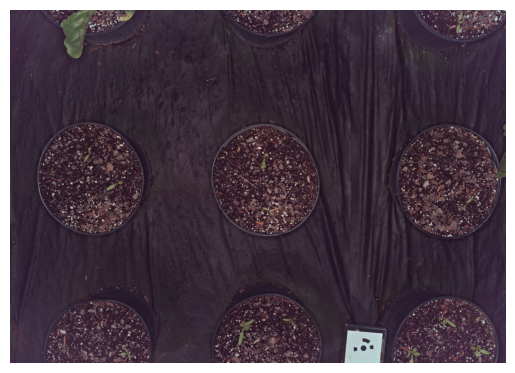

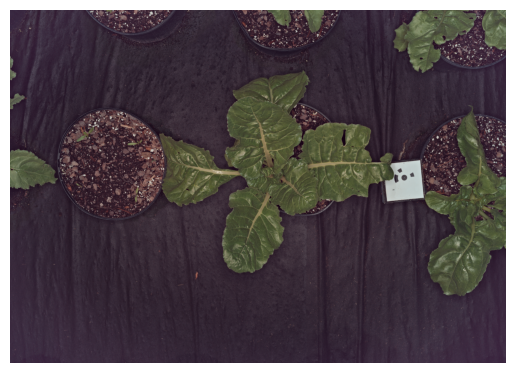

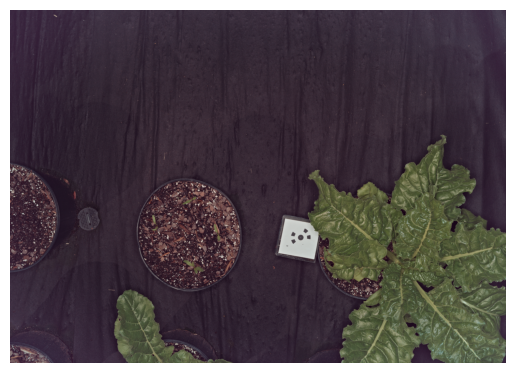

In [16]:
plt.close('all')

sample_n = 3
random_sample = random.sample(imgs, min(sample_n, len(imgs)))
for img_path in random_sample:
    print(img_path)
    img = cv2.imread(str(img_path))
    # create a center crop inset with zoomed in view
    h, w = img.shape[:2]
    center_crop = img[h//4:3*h//4, w//4:3*w//4]
    # reszie by 0.25 because images are too large
    img = cv2.resize(img, (0,0), fx=0.25, fy=0.25)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis('off')
    plt.show()
# clear all plots
plt.close('all')


In [ ]:
old = "/home/mkutuga/SemiF-Preprocessing/MD_1759502864.jpg"
new = "/home/mkutuga/svs-raw-api/data/jpgs/MD_2025-10-09/MD_1759502864.jpg"

[PosixPath('/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-10-03/images/MD_1759501879.jpg'),
 PosixPath('/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-10-03/images/MD_1759502864.jpg'),
 PosixPath('/mnt/research-projects/s/screberg/longterm_images2/semifield-developed-images/MD_2025-10-03/images/MD_1759505032.jpg')]